``AAPredPlot().predict_sample(data, kind=...)`` visualizes single-protein positional predictions: the per-residue profile (``kind='window'``) and the domain boundary-sensitivity curve (``kind='domain'``). ``kind`` selects the renderer and ``data`` is the matching :meth:`AAPred.predict` frame. We first fit an ``AAPred`` and generate the predictions to visualize (see [Breimann25]_):

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity
aa.plot_settings()

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))
aapred = aa.AAPred(df_feat=df_feat, random_state=42).fit(X, labels)
aapred_plot = aa.AAPredPlot()

# Per-residue and per-domain predictions for one protein (APP, P05067)
one = df_seq[df_seq["entry"] == "P05067"]
df_window = aapred.predict(one[["entry", "sequence"]], level="window", tmd_len=15, step=5)
df_domain = aapred.predict(one, level="domain", window=5)

**Per-residue profile.** ``kind='window'`` draws the profile with an optional decision ``threshold``, annotation tracks (``list_annotations``), a line ``color`` and axis labels; ``entry`` selects the protein when ``data`` holds several:

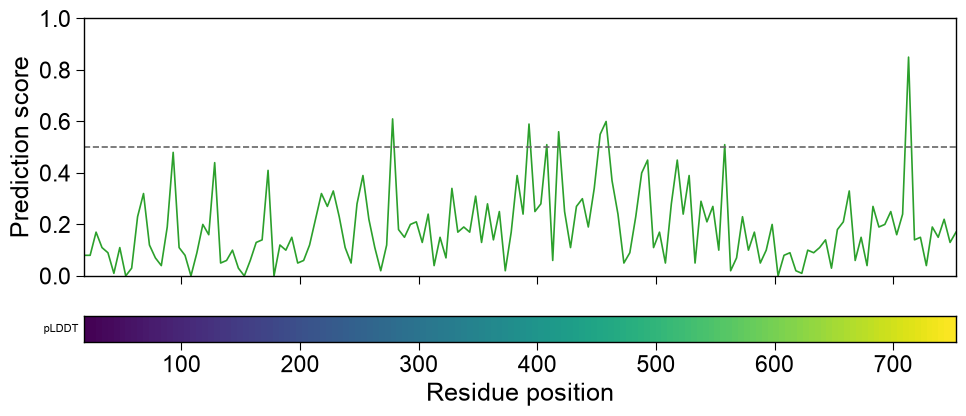

In [2]:
n_pos = len(df_window)
list_annotations = [{"values": np.linspace(0, 1, n_pos), "label": "pLDDT", "cmap": "viridis"}]
aapred_plot.predict_sample(data=df_window, kind="window", entry="P05067", threshold=0.5,
                           list_annotations=list_annotations, color="tab:green", figsize=(10, 4.5),
                           xlabel="Residue position", ylabel="Prediction score")
plt.tight_layout()
plt.show()

**Boundary sensitivity.** ``kind='domain'`` shows how the score depends on the exact domain boundary; the best offset is starred:

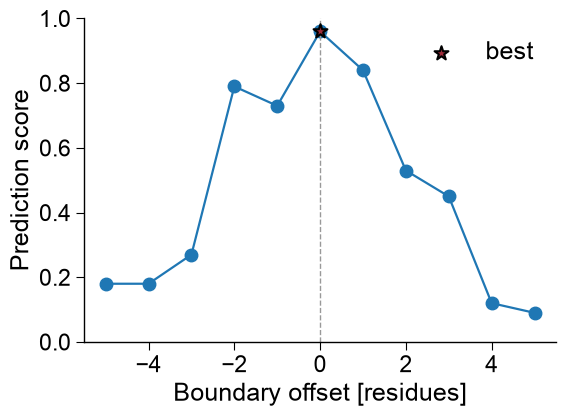

In [3]:
aapred_plot.predict_sample(data=df_domain, kind="domain", entry="P05067", color="tab:blue",
                           figsize=(6, 4.5), xlabel="Boundary offset [residues]",
                           ylabel="Prediction score")
plt.tight_layout()
plt.show()